In [1]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [30]:
# Download latest version
path = kagglehub.dataset_download("zalando-research/fashionmnist")
os.listdir(path)

# Read data
df = pd.read_csv(os.path.join(path, "fashion-mnist_train.csv"))

## EDA


In [38]:
# Print information
print("Shape:", df.shape)
print(df.dtypes)

display(df.head())

Shape: (60000, 785)
label       int64
pixel1      int64
pixel2      int64
pixel3      int64
pixel4      int64
            ...  
pixel780    int64
pixel781    int64
pixel782    int64
pixel783    int64
pixel784    int64
Length: 785, dtype: object


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Visualización de imágenes

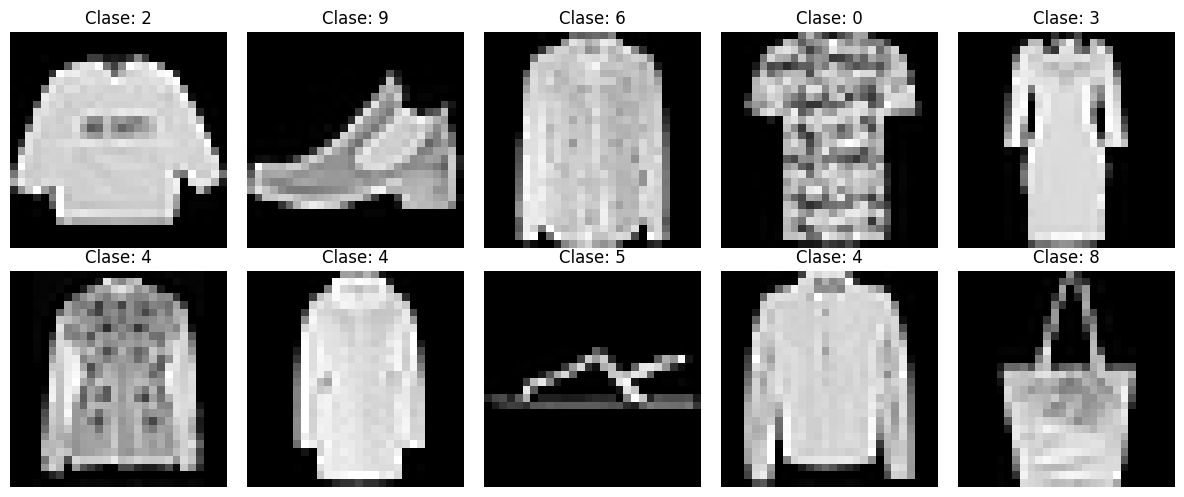

In [32]:
# Plot first 10 images

X_train = df.drop("label", axis=1)
X = X_train.values

y = df["label"].values

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Clase: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()


### Distribución de clases

La distribución de las clases es equilibrada, ya que cada una de las 10 categorías contiene 6000 imágenes. Esto significa que no existe un desbalance entre las clases del conjunto de datos, por lo que todas las categorías tienen la misma representación y no es necesario aplicar técnicas de balanceo de clases.


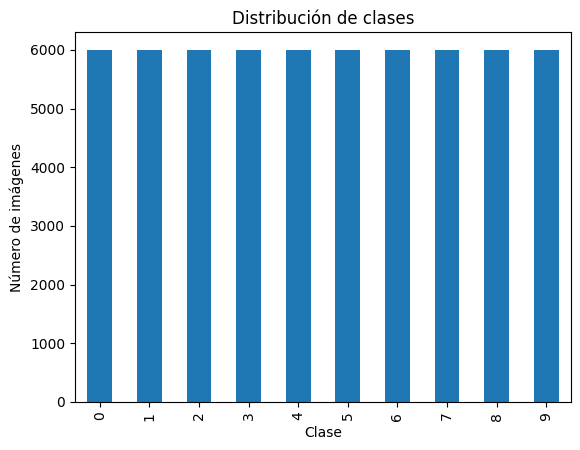

label
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64


In [ ]:
# Distribución de clases

df["label"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.title("Distribución de clases")
plt.show()

print(df["label"].value_counts().sort_index())

### Missing values

No se encontraron valores nulos en el conjunto de datos. Esto indica que todas las imágenes cuentan con información en sus atributos de píxeles y que no es necesario realizar un proceso de imputación de valores faltantes.


In [49]:

print("Missing values:", df.isnull().sum().sum())


Missing values: 0


### Estadísticas de los píxeles

La intensidad de los píxeles se encuentran entre 0 y 255, donde 0 representa ausencia de intensidad y 255 corresponde a la máxima intensidad. La media de 72.96 indica que, en promedio, los píxeles presentan una intensidad relativamente baja. Esto es coherente el dataset de Fashion-MNIST, ya que las prendas suelen estar representadas sobre un fondo oscuro. La desviación estándar de 89.97 muestra una dispersión considerable en los valores de intensidad, lo que indica que existe una diferencia importante entre las zonas oscuras y las zonas que contienen información visual de las prendas. No se identifican valores fuera del rango esperado, dado que el mínimo es 0 y el máximo 255.


In [ ]:
print("Mean: ", X.mean())
print("Std: ", X.std())
print("Min: ", X.min())
print("Max: ", X.max())


Mean:  72.9568306122449
Std:  89.9668629851211
Min:  0
Max:  255


### Distribución de intensidades

La distribución de intensidades muestra valores entre 0 y 255, correspondientes a una imagen en escala de grises. Se observa una alta frecuencia de píxeles con intensidad 0, lo que indica una importante presencia de zonas oscuras o de fondo en las imágenes. También se presentan valores elevados de intensidad, correspondientes principalmente a las zonas donde se encuentran las prendas. Esta distribución confirma la variabilidad de intensidad presente en las imágenes y permite identificar la necesidad de normalizar los valores durante el preprocesamiento.


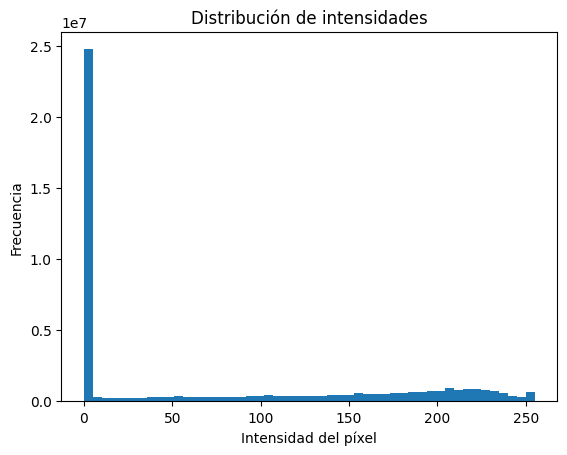

In [43]:
plt.hist(X.flatten(), bins=50)
plt.xlabel("Intensidad del píxel")
plt.ylabel("Frecuencia")
plt.title("Distribución de intensidades")
plt.show()
